Se creó el archivo de ejemplo: dataset_tabular.csv

COLUMNAS UTILIZADAS
largo_sepalo, ancho_sepalo, largo_petalo, ancho_petalo

RESULTADOS DEL PCA
Columnas originales: 4
Componentes seleccionados: 2
Varianza total conservada: 95.81%

VARIANZA POR COMPONENTE
componente_1: 72.96%
componente_2: 22.85%

PRIMERAS FILAS DEL DATASET REDUCIDO
 id  componente_1  componente_2 etiqueta
  1     -2.264703      0.480027   setosa
  2     -2.080961     -0.674134   setosa
  3     -2.364229     -0.341908   setosa
  4     -2.299384     -0.597395   setosa
  5     -2.389842      0.646835   setosa

Dataset reducido guardado como: dataset_reducido_pca.csv
Modelo PCA guardado como: modelo_pca.pkl


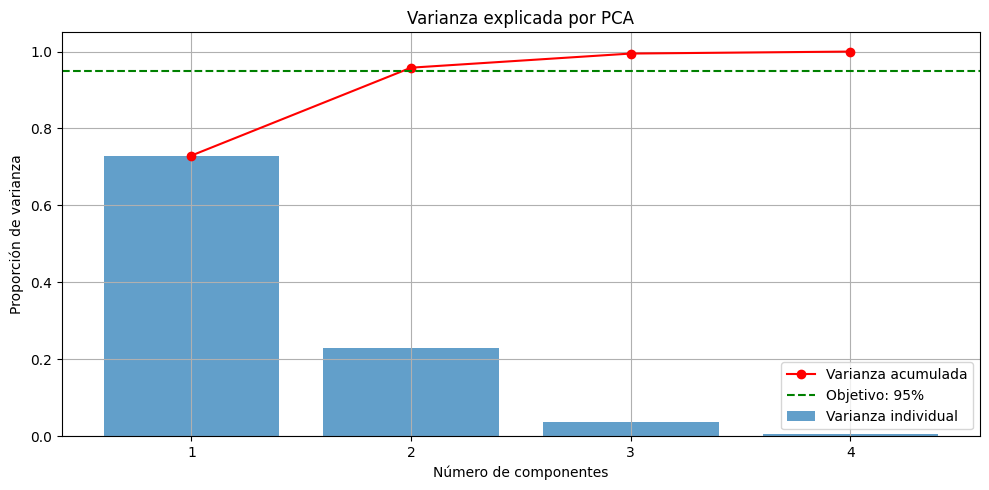

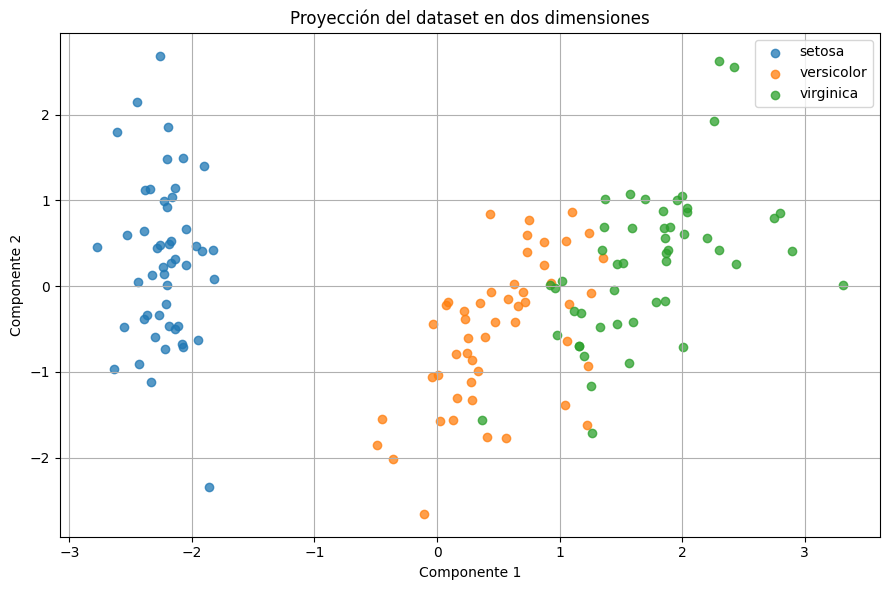

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ==========================================
# 1. Configuración
# ==========================================

ARCHIVO_DATOS = "dataset_tabular.csv"
ARCHIVO_RESULTADO = "dataset_reducido_pca.csv"
ARCHIVO_MODELO = "modelo_pca.pkl"

COLUMNA_ID = "id"
COLUMNA_ETIQUETA = "etiqueta"

VARIANZA_DESEADA = 0.95


# ==========================================
# 2. Crear un dataset de ejemplo
# ==========================================

if not os.path.exists(ARCHIVO_DATOS):
    iris = load_iris()

    datos_ejemplo = pd.DataFrame(
        iris.data,
        columns=[
            "largo_sepalo",
            "ancho_sepalo",
            "largo_petalo",
            "ancho_petalo"
        ]
    )

    datos_ejemplo.insert(
        0,
        COLUMNA_ID,
        range(1, len(datos_ejemplo) + 1)
    )

    datos_ejemplo[COLUMNA_ETIQUETA] = iris.target_names[
        iris.target
    ]

    datos_ejemplo.to_csv(
        ARCHIVO_DATOS,
        index=False,
        encoding="utf-8"
    )

    print(f"Se creó el archivo de ejemplo: {ARCHIVO_DATOS}")


# ==========================================
# 3. Cargar el dataset
# ==========================================

try:
    datos = pd.read_csv(
        ARCHIVO_DATOS,
        encoding="utf-8"
    )
except FileNotFoundError:
    print(f"No se encontró el archivo '{ARCHIVO_DATOS}'.")
    exit()


# ==========================================
# 4. Identificar columnas numéricas
# ==========================================

columnas_excluidas = [
    COLUMNA_ID,
    COLUMNA_ETIQUETA
]

columnas_numericas = datos.select_dtypes(
    include=np.number
).columns.tolist()

columnas_numericas = [
    columna
    for columna in columnas_numericas
    if columna not in columnas_excluidas
]

if len(columnas_numericas) < 2:
    print(
        "El dataset debe tener al menos dos columnas numéricas."
    )
    exit()


print("\nCOLUMNAS UTILIZADAS")
print("===================")
print(", ".join(columnas_numericas))


# ==========================================
# 5. Limpiar los datos
# ==========================================

datos_trabajo = datos.copy()

for columna in columnas_numericas:
    datos_trabajo[columna] = pd.to_numeric(
        datos_trabajo[columna],
        errors="coerce"
    )

datos_trabajo = datos_trabajo.dropna(
    subset=columnas_numericas
).reset_index(drop=True)

X = datos_trabajo[columnas_numericas]


# ==========================================
# 6. Estandarizar las variables
# ==========================================

escalador = StandardScaler()

X_escalado = escalador.fit_transform(X)


# ==========================================
# 7. Calcular todos los componentes
# ==========================================

pca_completo = PCA()

X_pca_completo = pca_completo.fit_transform(
    X_escalado
)

varianza_individual = (
    pca_completo.explained_variance_ratio_
)

varianza_acumulada = np.cumsum(
    varianza_individual
)


# ==========================================
# 8. Seleccionar componentes automáticamente
# ==========================================

cantidad_componentes = np.argmax(
    varianza_acumulada >= VARIANZA_DESEADA
) + 1

cantidad_componentes = min(
    cantidad_componentes,
    len(columnas_numericas)
)

pca = PCA(
    n_components=cantidad_componentes
)

X_reducido = pca.fit_transform(
    X_escalado
)


# ==========================================
# 9. Crear dataset reducido
# ==========================================

nombres_componentes = [
    f"componente_{i + 1}"
    for i in range(cantidad_componentes)
]

datos_reducidos = pd.DataFrame(
    X_reducido,
    columns=nombres_componentes
)

if COLUMNA_ID in datos_trabajo.columns:
    datos_reducidos.insert(
        0,
        COLUMNA_ID,
        datos_trabajo[COLUMNA_ID].values
    )

if COLUMNA_ETIQUETA in datos_trabajo.columns:
    datos_reducidos[COLUMNA_ETIQUETA] = (
        datos_trabajo[COLUMNA_ETIQUETA].values
    )


# ==========================================
# 10. Mostrar resultados
# ==========================================

varianza_explicada = pca.explained_variance_ratio_
varianza_total = varianza_explicada.sum()

print("\nRESULTADOS DEL PCA")
print("==================")
print(f"Columnas originales: {len(columnas_numericas)}")
print(f"Componentes seleccionados: {cantidad_componentes}")
print(
    f"Varianza total conservada: "
    f"{varianza_total:.2%}"
)

print("\nVARIANZA POR COMPONENTE")
print("=======================")

for nombre, porcentaje in zip(
    nombres_componentes,
    varianza_explicada
):
    print(f"{nombre}: {porcentaje:.2%}")

print("\nPRIMERAS FILAS DEL DATASET REDUCIDO")
print("===================================")
print(datos_reducidos.head().to_string(index=False))


# ==========================================
# 11. Guardar el dataset reducido
# ==========================================

datos_reducidos.to_csv(
    ARCHIVO_RESULTADO,
    index=False,
    encoding="utf-8"
)

print(
    f"\nDataset reducido guardado como: "
    f"{ARCHIVO_RESULTADO}"
)


# ==========================================
# 12. Guardar el modelo PCA
# ==========================================

modelo_guardado = {
    "escalador": escalador,
    "pca": pca,
    "columnas_numericas": columnas_numericas,
    "varianza_deseada": VARIANZA_DESEADA
}

joblib.dump(
    modelo_guardado,
    ARCHIVO_MODELO
)

print(
    f"Modelo PCA guardado como: "
    f"{ARCHIVO_MODELO}"
)


# ==========================================
# 13. Proyectar nuevos datos
# ==========================================

def transformar_nuevos_datos(
    nuevos_datos,
    modelo_guardado
):
    columnas = modelo_guardado[
        "columnas_numericas"
    ]

    escalador_guardado = modelo_guardado[
        "escalador"
    ]

    pca_guardado = modelo_guardado[
        "pca"
    ]

    datos_nuevos = nuevos_datos[columnas]

    datos_nuevos_escalados = (
        escalador_guardado.transform(
            datos_nuevos
        )
    )

    datos_nuevos_pca = (
        pca_guardado.transform(
            datos_nuevos_escalados
        )
    )

    nombres = [
        f"componente_{i + 1}"
        for i in range(
            pca_guardado.n_components_
        )
    ]

    return pd.DataFrame(
        datos_nuevos_pca,
        columns=nombres
    )


# ==========================================
# 14. Visualizar la varianza explicada
# ==========================================

plt.figure(figsize=(10, 5))

componentes = range(
    1,
    len(varianza_individual) + 1
)

plt.bar(
    componentes,
    varianza_individual,
    alpha=0.7,
    label="Varianza individual"
)

plt.plot(
    componentes,
    varianza_acumulada,
    marker="o",
    color="red",
    label="Varianza acumulada"
)

plt.axhline(
    VARIANZA_DESEADA,
    color="green",
    linestyle="--",
    label=f"Objetivo: {VARIANZA_DESEADA:.0%}"
)

plt.xlabel("Número de componentes")
plt.ylabel("Proporción de varianza")
plt.title("Varianza explicada por PCA")
plt.xticks(list(componentes))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# 15. Visualizar los dos primeros componentes
# ==========================================

if cantidad_componentes >= 2:
    plt.figure(figsize=(9, 6))

    if COLUMNA_ETIQUETA in datos_reducidos.columns:
        etiquetas = datos_reducidos[
            COLUMNA_ETIQUETA
        ].astype(str)

        for etiqueta in etiquetas.unique():
            seleccion = etiquetas == etiqueta

            plt.scatter(
                datos_reducidos.loc[
                    seleccion,
                    "componente_1"
                ],
                datos_reducidos.loc[
                    seleccion,
                    "componente_2"
                ],
                label=etiqueta,
                alpha=0.75
            )
    else:
        plt.scatter(
            datos_reducidos["componente_1"],
            datos_reducidos["componente_2"],
            alpha=0.75
        )

    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.title("Proyección del dataset en dos dimensiones")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()